# Graph RAG: Safe Text-to-Cypher Question Answering

**Chapter 23: Knowledge Graphs for Financial AI**

**Docker image**: `ml4t`

> **Neo4j required**: This notebook queries a Neo4j graph database.
> Start Neo4j first, then run the notebook:
> ```bash
> docker compose --profile kg up -d neo4j
> docker compose run --rm ml4t python 23_knowledge_graphs/03_graph_rag_qa.py
> ```


This notebook demonstrates a safe Graph RAG workflow over the real 13F
institutional holdings graph loaded into Neo4j by `05_institutional_holdings_kg`.

**Learning Objectives**:
- Implement controlled text-to-Cypher translation for institutional holdings questions
- Validate generated Cypher against a read-only schema policy
- Enforce dated queries, row limits, and explicit setup checks
- Audit query validity, provenance coverage, and temporal filtering on live graph results

**Book Reference**: Chapter 23, Section 23.3 (Graph RAG: Deterministic Relational Reasoning)

**Prerequisites**: Run `05_institutional_holdings_kg` to load the 13F graph into
Neo4j. This notebook requires a live Neo4j connection and does not use canned
query results.

In [1]:
"""Run controlled read-only Cypher queries over institutional holdings."""

from __future__ import annotations

import hashlib
import json
import logging
import os
import re
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
from neo4j import GraphDatabase, Query

from utils.style import COLORS, FIGSIZE, add_message_title

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

In [2]:
ROW_LIMIT = 25
TIMEOUT_SECONDS = 2.0
# Point-in-time as-of date. Holdings filed after this date are invisible to the
# queries. Set to the latest 13F vintage in the graph; the negative control below
# uses an earlier date to prove the filter actually constrains the evidence.
CUTOFF_DATE = "2026-02-17"

## 1. Neo4j Connection and Safety Policy

In [3]:
NEO4J_URI = os.getenv("NEO4J_URI", "bolt://localhost:7687")
NEO4J_USER = os.getenv("NEO4J_USER", "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD", "password")

NEO4J_DRIVER = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
NEO4J_DRIVER.verify_connectivity()
print(f"Neo4j connected: {NEO4J_URI}")

GRAPH_SCHEMA: dict[str, Any] = {
    "labels": {"Institution", "Stock", "Sector"},
    "relationships": {"HOLDS", "IN_SECTOR"},
    "properties": {"aum", "cik", "cusip", "issuer", "name", "quarter", "sector", "shares", "value"},
}

BLOCKED_KEYWORDS = {
    "CALL",
    "CREATE",
    "DELETE",
    "DETACH",
    "DROP",
    "LOAD CSV",
    "MERGE",
    "REMOVE",
    "SET",
}

print("Schema labels:", sorted(GRAPH_SCHEMA["labels"]))
print("Schema relationships:", sorted(GRAPH_SCHEMA["relationships"]))

Neo4j connected: bolt://neo4j:7687
Schema labels: ['Institution', 'Sector', 'Stock']
Schema relationships: ['HOLDS', 'IN_SECTOR']


### Producer Snapshot Contract

The query layer accepts only the fixed-cohort graph produced from the current 13F bytes.

In [4]:
source_path = (
    Path(os.environ["ML4T_DATA_PATH"])
    / "equities"
    / "positioning"
    / "13f"
    / "institutional_holdings.parquet"
)
expected_source_hash = hashlib.sha256(source_path.read_bytes()).hexdigest()
with NEO4J_DRIVER.session(default_access_mode="READ") as session:
    snapshot_record = session.run(
        "MATCH (s:GraphSnapshot {name: 'ch23_13f'}) RETURN properties(s) AS snapshot"
    ).single()
    graph_counts = (
        session.run(
            """
        MATCH (i:Institution) WITH count(i) AS institutions
        MATCH (s:Stock) WITH institutions, count(s) AS stocks
        MATCH (:Institution)-[h:HOLDS]->(:Stock)
        WITH institutions, stocks, count(h) AS holdings
        MATCH (:Stock)-[r:IN_SECTOR]->(:Sector)
        RETURN institutions, stocks, holdings, count(r) AS sector_edges
        """
        )
        .single()
        .data()
    )
assert snapshot_record is not None, "Run 05_institutional_holdings_kg before this notebook"
GRAPH_SNAPSHOT = snapshot_record["snapshot"]
assert GRAPH_SNAPSHOT["source_sha256"] == expected_source_hash
assert GRAPH_SNAPSHOT["latest_quarter"] == CUTOFF_DATE
assert GRAPH_SNAPSHOT["cohort_policy"] == "earliest-vintage formation, fixed forward"
assert graph_counts == {
    "institutions": GRAPH_SNAPSHOT["institution_count"],
    "stocks": GRAPH_SNAPSHOT["stock_count"],
    "holdings": GRAPH_SNAPSHOT["holding_count"],
    "sector_edges": GRAPH_SNAPSHOT["stock_count"],
}
print(f"Validated graph snapshot: {GRAPH_SNAPSHOT}")

Validated graph snapshot: {'institution_count': 10, 'stock_count': 50, 'source_sha256': '6f27cbe8d2574861b8a97ddd6958a93234b062f3b10b0b9ebe46723c772e6c1d', 'holding_count': 1490, 'latest_quarter': '2026-02-17', 'name': 'ch23_13f', 'vintage_count': 4, 'formation_quarter': '2025-05-15', 'source_rows': 201145, 'cohort_policy': 'earliest-vintage formation, fixed forward'}


## 2. Controlled Text-to-Cypher Templates

Each template constrains the HOLDS vintage to `h.quarter <= $cutoff_date` and
then keeps only the latest position per (institution, stock) before ordering
(`collect(h)[0]` after `ORDER BY h.quarter DESC`). This is the point-in-time
semantics readers want: a single most-recent position per holder as of the
cutoff, not the cross-product of every historical filing the institution made
for that stock.

In [5]:
HOLDERS_SPEC = {
    "cypher": """
MATCH (i:Institution)-[h:HOLDS]->(s:Stock)
WHERE replace(s.issuer, " ", "") = replace($issuer, " ", "")
  AND h.quarter <= $cutoff_date
WITH i, s, h ORDER BY h.quarter DESC
WITH i, s, collect(h)[0] AS latest_h
RETURN i.name AS institution,
       latest_h.value AS position_value,
       latest_h.shares AS shares,
       latest_h.quarter AS filing_date
ORDER BY position_value DESC
LIMIT 25
""".strip(),
    "params": {"issuer": "APPLE INC"},
    "kind": "holders",
}

In [6]:
CO_OWNERS_SPEC = {
    "cypher": """
MATCH (i:Institution)-[ha:HOLDS]->(a:Stock)
MATCH (i)-[hm:HOLDS]->(m:Stock)
WHERE replace(a.issuer, " ", "") = replace($issuer_1, " ", "")
  AND replace(m.issuer, " ", "") = replace($issuer_2, " ", "")
  AND ha.quarter <= $cutoff_date
  AND hm.quarter <= $cutoff_date
WITH i, a, m, ha, hm ORDER BY ha.quarter DESC, hm.quarter DESC
WITH i, a, m, collect(ha)[0] AS latest_a, collect(hm)[0] AS latest_m
RETURN i.name AS institution,
       latest_a.value AS issuer_1_value,
       latest_m.value AS issuer_2_value,
       latest_a.quarter AS issuer_1_filing_date,
       latest_m.quarter AS issuer_2_filing_date
ORDER BY issuer_1_value + issuer_2_value DESC
LIMIT 25
""".strip(),
    "params": {"issuer_1": "APPLE INC", "issuer_2": "MICROSOFT CORP"},
    "kind": "co_owners",
}

In [7]:
LARGEST_HOLDINGS_SPEC = {
    "cypher": """
MATCH (i:Institution {name: $institution})-[h:HOLDS]->(s:Stock)
WHERE h.quarter <= $cutoff_date
WITH i, s, h ORDER BY h.quarter DESC
WITH s, collect(h)[0] AS latest_h
RETURN s.issuer AS issuer,
       latest_h.value AS position_value,
       latest_h.shares AS shares,
       latest_h.quarter AS filing_date
ORDER BY position_value DESC
LIMIT 10
""".strip(),
    "params": {"institution": "BERKSHIRE HATHAWAY INC"},
    "kind": "largest_holdings",
}

### Supported Question Router

In [8]:
QUESTION_SPECS = {
    "who holds apple": HOLDERS_SPEC,
    "which institutions own both apple and microsoft": CO_OWNERS_SPEC,
    "what are berkshire hathaway largest holdings": LARGEST_HOLDINGS_SPEC,
}


def text_to_cypher(question: str) -> tuple[str, dict[str, Any], str]:
    """Map a supported question to a pre-validated Cypher template."""
    normalized = question.lower().strip().rstrip("?")
    for key, spec in QUESTION_SPECS.items():
        if key in normalized:
            params = {"cutoff_date": CUTOFF_DATE, **spec["params"]}
            return spec["cypher"], params, spec["kind"]
    raise ValueError(f"Unsupported question: {question}")

## 3. Safety Validation

In [9]:
LABEL_PATTERN = re.compile(r"\([^\)]*:\s*([A-Za-z_][A-Za-z0-9_]*)")
REL_PATTERN = re.compile(r"\[[^\]]*:\s*([A-Za-z_][A-Za-z0-9_]*)\]")
PROPERTY_PATTERN = re.compile(r"\.([A-Za-z_][A-Za-z0-9_]*)")


def validate_cypher(cypher: str) -> tuple[bool, list[str]]:
    """Validate generated Cypher against a strict read-only policy."""
    issues: list[str] = []
    uppercase = cypher.upper()

    for keyword in BLOCKED_KEYWORDS:
        if keyword in uppercase:
            issues.append(f"Blocked keyword detected: {keyword}")

    labels = set(LABEL_PATTERN.findall(cypher))
    rels = set(REL_PATTERN.findall(cypher))
    props = set(PROPERTY_PATTERN.findall(cypher))

    for label in labels:
        if label not in GRAPH_SCHEMA["labels"]:
            issues.append(f"Unknown label: {label}")

    for rel in rels:
        if rel not in GRAPH_SCHEMA["relationships"]:
            issues.append(f"Unknown relationship: {rel}")

    for prop in props:
        if prop not in GRAPH_SCHEMA["properties"]:
            issues.append(f"Unknown property: {prop}")

    if "LIMIT" not in uppercase:
        issues.append("Missing LIMIT clause")

    if "$cutoff_date" not in cypher:
        issues.append("Missing cutoff_date parameter")

    return len(issues) == 0, issues

### Row-Limit Guard

Defensive clamp: if a template ever omits an explicit `LIMIT`, append one so a
single question can never stream an unbounded result set out of the database.

In [10]:
def enforce_query_limits(cypher: str) -> str:
    """Clamp query result size when a template omits LIMIT."""
    if "LIMIT" in cypher.upper():
        return cypher
    return f"{cypher}\nLIMIT {ROW_LIMIT}"

## 4. Read-Only Query Execution

In [11]:
def execute_read_only(cypher: str, params: dict[str, Any]) -> list[dict[str, Any]]:
    """Execute a validated read-only Cypher query against Neo4j."""
    query = Query(cypher, timeout=TIMEOUT_SECONDS)
    with NEO4J_DRIVER.session(default_access_mode="READ") as session:
        result = session.run(query, params)
        return [record.data() for record in result]

### Answer Synthesis

Turn the returned rows into a one-line natural-language answer. The summary only
restates values present in the result set. It never adds facts outside the
graph, so the answer stays auditable against the query provenance.

In [12]:
def synthesize_answer(kind: str, rows: list[dict[str, Any]]) -> str:
    """Summarize returned rows without inventing facts outside the graph."""
    if not rows:
        return "No supported evidence found before the requested cutoff date."

    # The staged value_thousands field is already dollar-valued despite its
    # legacy name, and notebook 05 preserves it without rescaling. Display the
    # graph value in $billions to keep the suffix unambiguous.
    if kind == "holders":
        top_rows = rows[:5]
        summary = ", ".join(
            f"{row['institution']} (${row['position_value'] / 1e9:,.1f}B)" for row in top_rows
        )
        return f"Top holders before the cutoff date: {summary}."

    if kind == "co_owners":
        institutions = ", ".join(row["institution"] for row in rows[:5])
        return f"Institutions holding both issuers before the cutoff date include {institutions}."

    top_rows = rows[:5]
    summary = ", ".join(
        f"{row['issuer']} (${row['position_value'] / 1e9:,.1f}B)" for row in top_rows
    )
    return f"Largest reported holdings before the cutoff date: {summary}."

## 5. End-to-End Example and Diagnostics

In [13]:
QUESTIONS = [
    "Who holds Apple?",
    "Which institutions own both Apple and Microsoft?",
    "What are Berkshire Hathaway largest holdings?",
]

metrics = {
    "query_validity": 0,
    "provenance_coverage": 0,
    "temporal_filter_present": 0,
}

for question in QUESTIONS:
    print(f"\nQuestion: {question}")

    cypher, params, kind = text_to_cypher(question)
    cypher = enforce_query_limits(cypher)
    ok, issues = validate_cypher(cypher)

    print("Generated Cypher:")
    print(cypher)

    if not ok:
        print("Validation failed:", issues)
        continue

    rows = execute_read_only(cypher, params)
    answer = synthesize_answer(kind, rows)

    print("Answer:")
    print(answer)

    metrics["query_validity"] += 1
    # Verify the cutoff actually constrains results: every returned row must be
    # dated on or before CUTOFF_DATE (not merely that the parameter is present).
    date_fields = (
        ("issuer_1_filing_date", "issuer_2_filing_date")
        if kind == "co_owners"
        else ("filing_date",)
    )
    metrics["temporal_filter_present"] += int(
        bool(rows) and all(row[field] <= CUTOFF_DATE for row in rows for field in date_fields)
    )
    metrics["provenance_coverage"] += int(
        bool(rows) and all(row.get(field) for row in rows for field in date_fields)
    )


Question: Who holds Apple?
Generated Cypher:
MATCH (i:Institution)-[h:HOLDS]->(s:Stock)
WHERE replace(s.issuer, " ", "") = replace($issuer, " ", "")
  AND h.quarter <= $cutoff_date
WITH i, s, h ORDER BY h.quarter DESC
WITH i, s, collect(h)[0] AS latest_h
RETURN i.name AS institution,
       latest_h.value AS position_value,
       latest_h.shares AS shares,
       latest_h.quarter AS filing_date
ORDER BY position_value DESC
LIMIT 25
Answer:
Top holders before the cutoff date: BERKSHIRE HATHAWAY INC ($62.0B), CITADEL ADVISORS LLC ($16.3B), MILLENNIUM MANAGEMENT LLC ($5.1B), AQR CAPITAL MANAGEMENT LLC ($3.4B), D. E. Shaw & Co., Inc. ($2.1B).

Question: Which institutions own both Apple and Microsoft?
Generated Cypher:
MATCH (i:Institution)-[ha:HOLDS]->(a:Stock)
MATCH (i)-[hm:HOLDS]->(m:Stock)
WHERE replace(a.issuer, " ", "") = replace($issuer_1, " ", "")
  AND replace(m.issuer, " ", "") = replace($issuer_2, " ", "")
  AND ha.quarter <= $cutoff_date
  AND hm.quarter <= $cutoff_date
WITH 

### Diagnostics

In [14]:
n = len(QUESTIONS)
print(f"Query validity:           {metrics['query_validity']}/{n}")
print(f"Point-in-time respected:  {metrics['temporal_filter_present']}/{n}")
print(f"Provenance coverage:      {metrics['provenance_coverage']}/{n}")
assert all(value == n for value in metrics.values()), f"Safety diagnostics failed: {metrics}"

Query validity:           3/3
Point-in-time respected:  3/3
Provenance coverage:      3/3


### Negative Control: the Cutoff Actually Constrains Evidence

A point-in-time parameter is only meaningful if moving it changes the result.
Re-run one question at an earlier cutoff and confirm it returns no future rows
and never more rows than the as-of date.

In [15]:
control_question = "Who holds Apple?"
control_cypher, control_params, _ = text_to_cypher(control_question)
control_cypher = enforce_query_limits(control_cypher)

rows_asof = execute_read_only(control_cypher, control_params)
# Pick a cutoff that strictly precedes the latest two 13F vintages. With binned
# quarter labels ['2025-05-15', '2025-08-14', '2025-11-14', '2026-02-17'],
# setting EARLIER_CUTOFF = '2025-09-01' makes the latest-per-institution roll
# back to the 2025-08-14 vintage. The point-in-time-latest templates return one
# row per institution either way, so the negative control checks that filings
# rolled back and position values differ. This proves the cutoff shifts
# the evidence rather than carrying the parameter unused.
EARLIER_CUTOFF = "2025-09-01"
rows_earlier = execute_read_only(control_cypher, {**control_params, "cutoff_date": EARLIER_CUTOFF})

In [16]:
asof_latest_q = max(row["filing_date"] for row in rows_asof) if rows_asof else None
earlier_latest_q = max(row["filing_date"] for row in rows_earlier) if rows_earlier else None
asof_values = {row["institution"]: row["position_value"] for row in rows_asof}
earlier_values = {row["institution"]: row["position_value"] for row in rows_earlier}
shared_holders = set(asof_values) & set(earlier_values)
shifted_holders = [h for h in shared_holders if asof_values[h] != earlier_values[h]]

print(
    f"Rows as of {CUTOFF_DATE}:        {len(rows_asof)} (latest filing_date in result: {asof_latest_q})"
)
print(
    f"Rows as of {EARLIER_CUTOFF} (earlier): {len(rows_earlier)} (latest filing_date in result: {earlier_latest_q})"
)
print(
    f"Shared holders across cutoffs: {len(shared_holders)} | position value shifted for: {len(shifted_holders)}"
)
assert all(row["filing_date"] <= CUTOFF_DATE for row in rows_asof), "future row leaked past cutoff"
assert all(row["filing_date"] <= EARLIER_CUTOFF for row in rows_earlier), (
    "earlier cutoff leaked future row"
)
assert earlier_latest_q is None or earlier_latest_q <= EARLIER_CUTOFF, (
    "earlier cutoff returned future vintage"
)
assert shifted_holders, (
    "earlier cutoff returned identical position values; cutoff is not constraining evidence"
)
print(
    "Point-in-time check passed: the earlier cutoff rolls latest filings back and shifts position values."
)

Rows as of 2026-02-17:        9 (latest filing_date in result: 2026-02-17)
Rows as of 2025-09-01 (earlier): 9 (latest filing_date in result: 2025-08-14)
Shared holders across cutoffs: 9 | position value shifted for: 9
Point-in-time check passed: the earlier cutoff rolls latest filings back and shifts position values.


### Safety Diagnostic Summary

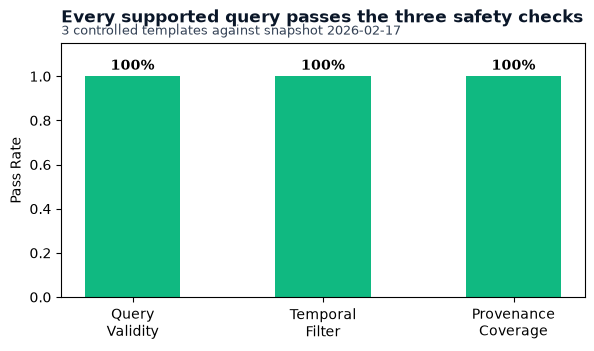

In [17]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
metric_names = ["Query\nValidity", "Temporal\nFilter", "Provenance\nCoverage"]
metric_values = [
    metrics["query_validity"] / n,
    metrics["temporal_filter_present"] / n,
    metrics["provenance_coverage"] / n,
]
bars = ax.bar(metric_names, metric_values, color=COLORS["positive"], width=0.5)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Pass Rate")
add_message_title(
    ax,
    "Every supported query passes the three safety checks",
    subtitle=f"{n} controlled templates against snapshot {GRAPH_SNAPSHOT['latest_quarter']}",
)
for bar, val in zip(bars, metric_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{val:.0%}",
        ha="center",
        fontweight="bold",
    )
fig.show()

### Machine-Readable Completion Record

In [18]:
completion_record = {
    "source_sha256": expected_source_hash,
    "formation_quarter": GRAPH_SNAPSHOT["formation_quarter"],
    "latest_quarter": GRAPH_SNAPSHOT["latest_quarter"],
    **graph_counts,
    "query_count": n,
    "co_owner_date_fields": 2,
    **metrics,
    "asof_latest_filing": asof_latest_q,
    "earlier_latest_filing": earlier_latest_q,
    "shared_holders": len(shared_holders),
    "shifted_holders": len(shifted_holders),
}
print("COMPLETION_RECORD=" + json.dumps(completion_record, sort_keys=True))
NEO4J_DRIVER.close()

COMPLETION_RECORD={"asof_latest_filing": "2026-02-17", "co_owner_date_fields": 2, "earlier_latest_filing": "2025-08-14", "formation_quarter": "2025-05-15", "holdings": 1490, "institutions": 10, "latest_quarter": "2026-02-17", "provenance_coverage": 3, "query_count": 3, "query_validity": 3, "sector_edges": 50, "shared_holders": 9, "shifted_holders": 9, "source_sha256": "6f27cbe8d2574861b8a97ddd6958a93234b062f3b10b0b9ebe46723c772e6c1d", "stocks": 50, "temporal_filter_present": 3}


**Interpretation**: All three diagnostic metrics should be N/N for a safe
Graph RAG deployment. Query validity confirms that templated Cypher stays
within the authorized holdings schema. The point-in-time metric verifies that
every returned row is dated on or before the cutoff, and the negative control
above shows an earlier cutoff strictly excludes later filings, so the filter
genuinely prevents lookahead rather than merely carrying the parameter.
Provenance coverage ensures every returned row carries its filing date.

## 6. Notes

- This notebook executes against the live holdings graph rather than canned rows.
- Production deployment should add server-side query whitelisting, RBAC,
  query plan checks, and audit logging.

## Key Takeaways

1. **Template-based safety** keeps the text-to-Cypher surface narrow enough to audit.
2. **Schema enforcement** blocks labels, relationships, and properties outside the holdings graph.
3. **Cutoff-date parameters** preserve point-in-time correctness for historical questions.
4. **Live graph execution** is only credible when Neo4j is actually populated with the chapter's 13F data.

**Next**: See `04_rag_comparison_benchmark.py` for a real-data retrieval benchmark
comparing structured graph retrieval with vector retrieval over the same holdings corpus.